<a href="https://colab.research.google.com/github/NazHub1993/Potato_Disease_Predictor_Project/blob/main/Potato_Disease_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/Potato_Disease_Predictor_models"

In [6]:
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3
EPOCHS=7

In [7]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [8]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [9]:
len(dataset)

68

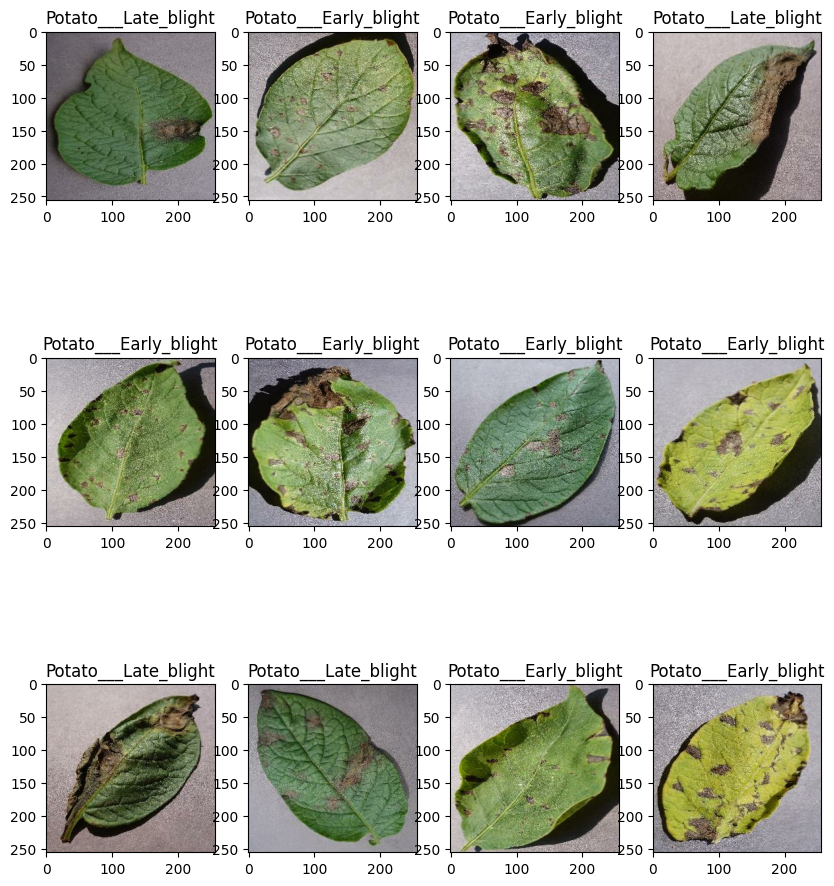

In [10]:
plt.figure(figsize=(10,12))
for image_batch,label_batch in dataset.take(1):
  for i in range(12):
    ax=plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype('uint8'))
    plt.title(class_names[label_batch[i].numpy()])

#Partitioning the dataset for train and test


In [11]:
def get_dataset_partitions(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=1000):
  ds_size=len(dataset)
  if shuffle:
    ds=ds.shuffle(shuffle_size,seed=12)

  train_size=int(train_split*ds_size)
  val_size=int(val_split*ds_size)

  train_ds=dataset.take(train_size)
  val_ds=dataset.skip(train_size).take(val_size)
  test_ds=dataset.skip(train_size).skip(val_size)

  return train_ds,val_ds,test_ds

In [12]:
train_ds,val_ds,test_ds=get_dataset_partitions(dataset)

In [18]:
len(train_ds)

54

In [19]:
len(val_ds)

6

In [20]:
len(test_ds)

8

In [13]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

#Adding the preprocessing layers

In [14]:
resize_rescale=tf.keras.Sequential(
    [
        layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
        layers.Rescaling(1.0/255)
    ]
)

In [15]:
data_augmentation=tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2)
    ]
)

In [16]:
healthy_ds = train_ds.filter(lambda x, y: tf.reduce_any(tf.equal(y, 2)))
diseased_ds = train_ds.filter(lambda x, y: tf.reduce_any(tf.not_equal(y, 2)))

# 2. Define a function to apply augmentation
def augment_healthy(image, label):
    # This only runs on the healthy images
    image = data_augmentation(image, training=True)
    return image, label

# 3. Create an "Extra" augmented dataset from the healthy samples
# We repeat it to increase the count to match the others
augmented_healthy_ds = healthy_ds.repeat(7).map(augment_healthy, num_parallel_calls=tf.data.AUTOTUNE)

# 4. Concatenate them back together
# You can repeat the healthy_ds multiple times to reach ~1000 images
train_ds_balanced = diseased_ds.concatenate(healthy_ds).concatenate(augmented_healthy_ds)

# 5. Shuffle again so the model doesn't see all healthy leaves in a row
train_ds = train_ds_balanced.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

#Building the CNN model

In [17]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes=3

from tensorflow.keras import models
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout,BatchNormalization



In [18]:
model=models.Sequential()

model.add(resize_rescale)
model.add(data_augmentation)

model.add(Conv2D(32,(3,3),activation='relu',padding='valid',input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,(3,3),activation='relu',padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,(3,3),activation='relu',padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,(3,3),activation='relu',padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,(3,3),activation='relu',padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(n_classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.build(input_shape=input_shape)

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 254, 254, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 125, 125, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 60, 60, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 28, 28, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (32, 12, 12, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 2304)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,043 (1.06 MB)

 Trainable params: 278,467 (1.06 MB)

 Non-trainable params: 576 (2.25 KB)

In [21]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [24]:
history=model.fit(train_ds,
          epochs=50,
          batch_size=BATCH_SIZE,
          verbose=1,
          validation_data=val_ds)

Epoch 1/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 85s 138ms/step - accuracy: 0.9893 - loss: 0.0356 - val_accuracy: 0.9635 - val_loss: 0.1814
Epoch 2/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 83s 138ms/step - accuracy: 0.9926 - loss: 0.0263 - val_accuracy: 0.8021 - val_loss: 1.2086
Epoch 3/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.9964 - loss: 0.0088 - val_accuracy: 0.9896 - val_loss: 0.0473
Epoch 4/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.9909 - loss: 0.0344 - val_accuracy: 0.9948 - val_loss: 0.0210
Epoch 5/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 83s 138ms/step - accuracy: 0.9961 - loss: 0.0133 - val_accuracy: 0.8177 - val_loss: 1.4554
Epoch 6/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 82s 137ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0.9740 - val_loss: 0.0684
Epoch 7/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 83s 138ms/step - accuracy: 0.9976 - loss: 0.0098 - val_accuracy: 0.7865 - val_loss: 1.8570
Epoch 8/50
454/454 ━━━━━━━━━━━━━━━━━━━━ 83s 138ms/step - accuracy: 0.9953 - loss: 0

In [26]:
history

In [25]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': None}

In [ ]:
history.history.keys()

In [27]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

In [28]:
it=50

In [30]:
EPOCHS=50

Text(0.5, 1.0, 'Training and Validation Accuracy')

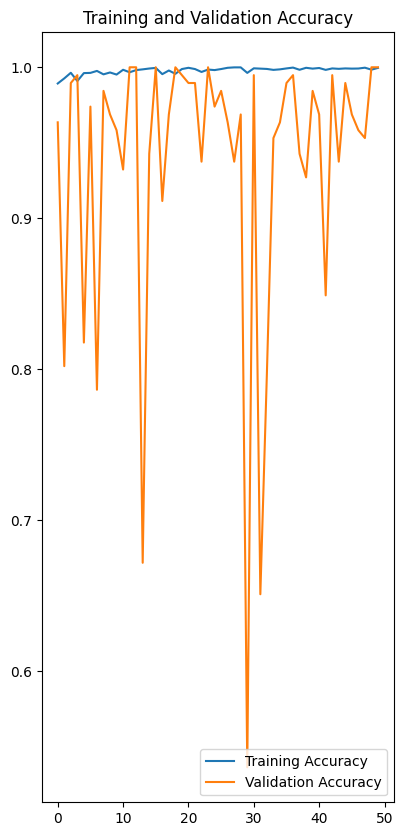

In [31]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label='Training Accuracy')
plt.plot(range(EPOCHS),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

Text(0.5, 1.0, 'Training and Validation Loss')

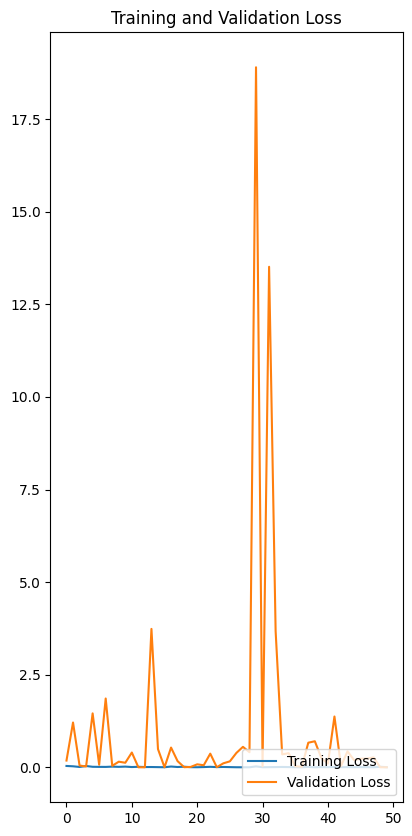

In [32]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label='Training Loss')
plt.plot(range(EPOCHS),val_loss,label='Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation Loss')

#Let's do the prediction!!!

In [33]:
import numpy as np

First Image to predict:
Actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
Predicted label:  Potato___Early_blight


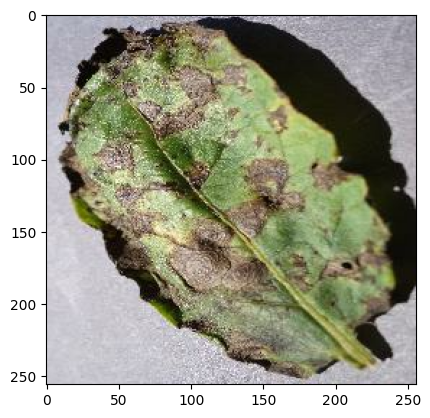

In [34]:
for image_batch,label_batch in test_ds.take(1):
  first_image=image_batch[0].numpy().astype('uint8')
  first_label=label_batch[0].numpy()

  print('First Image to predict:')
  plt.imshow(first_image)
  print("Actual label:",class_names[first_label])

  batch_prediction=model.predict(image_batch)
  print("Predicted label: ",class_names[np.argmax(batch_prediction[0])])

In [ ]:
def prediction(model, single_image_array):
  img_array=tf.keras.preprocessing.image.img_to_array(single_image_array)
  img_array=tf.expand_dims(img_array,0)

  predictions=model.predict(img_array)
  predicted_class=class_names[np.argmax(predictions[0])]

  confidence=round(100*(np.max(predictions)),2)
  return predicted_class,confidence

In [ ]:
plt.figure(figsize=(20,20))
for image_batch,label_batch in test_ds.take(1):
  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    current_image = image_batch[i].numpy().astype('uint8')
    plt.imshow(current_image)
    predicted_class,confidence=prediction(model, current_image)
    actual_class=class_names[np.argmax(label_batch[i].numpy())]
    plt.title(f"Actual : {actual_class},\n Predicted: {predicted_class},\n Confidence: {confidence}")
    print("Actual Class: ",actual_class)
    print("Predicted Class: ",predicted_class)

In [37]:
model_path = "/content/drive/MyDrive/Potato_Disease_Predictor/plant_model_4.keras"

# Save it
model.save(model_path)
print("Model saved to Google Drive!")

Model saved to Google Drive!
